Device: mps
Data: (5184, 22, 1000) classes: [1296 1296 1296 1296]
Subjects: ['1', '2', '3', '4', '5', '6', '7', '8', '9'] sessions: ['0train', '1test']


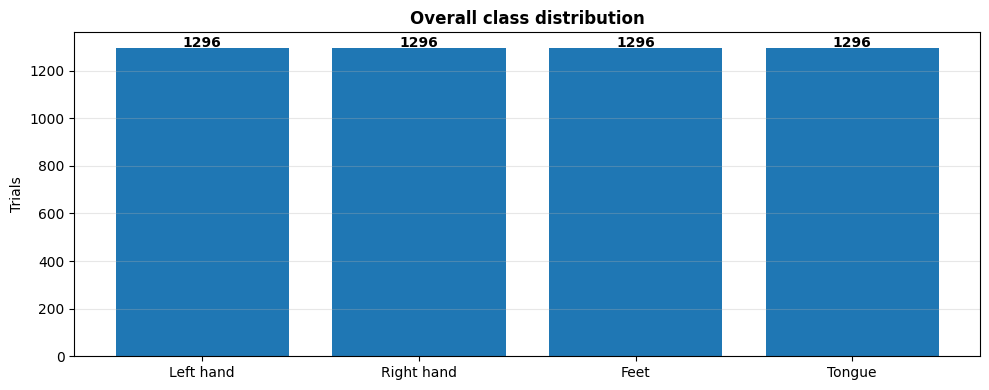

Subject Session  Trials  Left hand  Right hand  Feet  Tongue
      1  0train     288         72          72    72      72
      1   1test     288         72          72    72      72
      2  0train     288         72          72    72      72
      2   1test     288         72          72    72      72
      3  0train     288         72          72    72      72
      3   1test     288         72          72    72      72
      4  0train     288         72          72    72      72
      4   1test     288         72          72    72      72
      5  0train     288         72          72    72      72
      5   1test     288         72          72    72      72
      6  0train     288         72          72    72      72
      6   1test     288         72          72    72      72
      7  0train     288         72          72    72      72
      7   1test     288         72          72    72      72
      8  0train     288         72          72    72      72
      8   1test     288 

In [ ]:
# PAPER-FAITHFUL CRNN-DF + SPARSE-FBGAN
# Ready-to-run continuation module. Requires eeg_bundle.pkl beside this file.
# Set RUN_FULL_LOSO=True after validating the demo fold.

import os, gc, time, pickle, random, warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.signal import butter, sosfiltfilt, welch
from scipy.linalg import eigh
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.manifold import TSNE
import torch, torch.nn as nn, torch.nn.functional as F, torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

SEED=42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device=torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print("Device:",device)

# ======================== CONFIG ========================
BUNDLE_PATH="eeg_bundle.pkl"; FS=250; N_CH=22; N_T=1000; N_CLASSES=4
CLASSES=["Left hand","Right hand","Feet","Tongue"]
BANDS=[(1,4),(4,8),(8,12),(12,16),(16,20),(20,24),(24,28),(28,32),(32,35),(35,38)]
CSP_PER_CLASS=4; LASSO_MIN=8; LASSO_MAX=64
CRNN_EPOCHS=200; WARMUP=30; CRNN_BATCH=32; CRNN_LR=1e-4
LAM_CENTER=.10; LAM_INTER=.01; CENTER_ALPHA=.5; DROPOUT=.5
NOISE_DIM=1600; GAN_EPOCHS=300; GAN_BATCH=16; GAN_LR_G=2e-4; GAN_LR_D=2e-4
N_FAKE_PER_CLASS=750
RUN_DEMO=True; DEMO_SUBJECT="1"; RUN_FULL_LOSO=False

PAPER_CRNN={"1":65.51,"2":45.18,"3":78.62,"4":53.58,"5":55.64,"6":56.03,"7":71.28,"8":75.02,"9":70.78}
PAPER_GAN={"1":79.60,"2":54.25,"3":83.84,"4":60.93,"5":70.54,"6":62.18,"7":79.94,"8":82.01,"9":81.36}

# ======================== LOAD ========================
assert os.path.exists(BUNDLE_PATH), f"{BUNDLE_PATH} not found"
with open(BUNDLE_PATH,"rb") as f: bundle=pickle.load(f)
X_raw=np.asarray(bundle["X_raw"],np.float32)
y=np.asarray(bundle["y"],np.int64)
subjects=np.asarray(bundle["subjects"]).astype(str)
sessions=np.asarray(bundle["sessions"]).astype(str)
S0=str(bundle.get("S0",sorted(np.unique(sessions))[0]))
S1=str(bundle.get("S1",sorted(np.unique(sessions))[1]))
print("Data:",X_raw.shape,"classes:",np.bincount(y,minlength=4))
print("Subjects:",sorted(np.unique(subjects)),"sessions:",sorted(np.unique(sessions)))

# ======================== INFO MAP 1 ========================
plt.figure(figsize=(10,4)); counts=np.bincount(y,minlength=4)
plt.bar(CLASSES,counts); plt.title("Overall class distribution",fontweight="bold")
plt.ylabel("Trials"); plt.grid(axis="y",alpha=.3)
for i,v in enumerate(counts): plt.text(i,v+5,str(v),ha="center",fontweight="bold")
plt.tight_layout(); plt.show()

rows=[]
for s in sorted(np.unique(subjects),key=lambda z:int(z)):
    for sess in sorted(np.unique(sessions)):
        m=(subjects==s)&(sessions==sess); c=np.bincount(y[m],minlength=4)
        rows.append([s,sess,len(y[m]),*c])
print(pd.DataFrame(rows,columns=["Subject","Session","Trials",*CLASSES]).to_string(index=False))

# ======================== PREPROCESS ========================
def bandpass_np(X,lo,hi,fs=FS,order=4):
    sos=butter(order,[lo,hi],btype="bandpass",fs=fs,output="sos")
    return sosfiltfilt(sos,X,axis=-1).astype(np.float32)

def preprocess(X): return bandpass_np(X,1,38)

def prepare_fold(test_subj):
    test_subj=str(test_subj)
    ms=subjects!=test_subj
    mc=(subjects==test_subj)&(sessions==S0)
    mt=(subjects==test_subj)&(sessions==S1)
    Xs,Xc,Xt=preprocess(X_raw[ms]),preprocess(X_raw[mc]),preprocess(X_raw[mt])
    mu=Xs.mean((0,2),keepdims=True); sd=Xs.std((0,2),keepdims=True)+1e-6
    norm=lambda X:((X-mu)/sd).astype(np.float32)
    return norm(Xs),y[ms],norm(Xc),y[mc],norm(Xt),y[mt]

# ======================== FBCSP + LASSO ========================
def mean_cov(X):
    cs=[]
    for t in X:
        C=t@t.T; cs.append(C/(np.trace(C)+1e-10))
    return np.mean(cs,0)

def fit_binary_csp(Xp,Xn,n_comp=CSP_PER_CLASS):
    Cp,Cn=mean_cov(Xp),mean_cov(Xn)
    vals,vecs=eigh(Cp,Cp+Cn+1e-8*np.eye(Cp.shape[0]))
    vecs=vecs[:,np.argsort(vals)[::-1]]
    a=n_comp//2; b=n_comp-a
    return np.concatenate([vecs[:,:a],vecs[:,-b:]],1).astype(np.float32)

def csp_logvar(X, W):
    """
    X: [n_trials, n_channels, n_samples]
    W: [n_channels, n_filters]
    Returns: [n_trials, n_filters]
    """
    if X.ndim != 3:
        raise ValueError(f"X must be [N, C, T], got {X.shape}")
    if W.ndim != 2 or W.shape[0] != X.shape[1]:
        raise ValueError(f"W must be [C, F]={X.shape[1], 'F'}, got {W.shape}")

    # W.T: [filters, channels], X: [trials, channels, samples]
    Z = np.einsum("fc,nct->nft", W.T, X, optimize=True)

    v = np.var(Z, axis=-1)
    v /= v.sum(axis=1, keepdims=True) + 1e-10
    return np.log(v + 1e-10).astype(np.float32)
def fit_fbcsp(X,yv):
    feats=[]; filters=[]; meta=[]
    for bi,(lo,hi) in enumerate(BANDS):
        Xb=bandpass_np(X,lo,hi); bf=[]
        for cls in range(4):
            W=fit_binary_csp(Xb[yv==cls],Xb[yv!=cls])
            bf.append(csp_logvar(Xb,W))
            for wi in range(W.shape[1]):
                filters.append(W[:,wi]); meta.append((bi,cls,wi,lo,hi))
        feats.append(np.concatenate(bf,1))
    return np.concatenate(feats,1),np.stack(filters,1).astype(np.float32),meta

def fit_sparse_fbcsp(Xcal,ycal):
    Fv,W,meta=fit_fbcsp(Xcal,ycal)
    sc=StandardScaler(); Fs=sc.fit_transform(Fv)
    la=LassoCV(cv=5,max_iter=50000,random_state=SEED,n_jobs=-1).fit(Fs,ycal.astype(float))
    co=np.abs(la.coef_); idx=np.where(co>1e-10)[0]
    if len(idx)<LASSO_MIN: idx=np.argsort(co)[::-1][:LASSO_MIN]
    if len(idx)>LASSO_MAX: idx=idx[np.argsort(co[idx])[::-1][:LASSO_MAX]]
    idx=np.sort(idx)
    return {"W_sparse":W[:,idx],"meta_sparse":[meta[i] for i in idx],"idx":idx,"coef":co}

# ======================== CRNN-DF ========================
class CRNN_DF(nn.Module):
    def __init__(self,n_filters=32,hidden=64):
        super().__init__(); self.feature_dim=hidden
        self.conv=nn.Conv2d(1,n_filters,(N_CH,45),bias=False)
        self.bn=nn.BatchNorm2d(n_filters); self.act=nn.ReLU()
        self.drop1=nn.Dropout(DROPOUT)
        self.pool=nn.MaxPool2d((1,75),stride=(1,10))
        self.lstm=nn.LSTM(n_filters,hidden,num_layers=2,batch_first=True,dropout=DROPOUT)
        self.drop2=nn.Dropout(DROPOUT); self.fc=nn.Linear(hidden,4)
    def forward(self,x):
        x=x.unsqueeze(1); x=self.drop1(self.act(self.bn(self.conv(x))))
        x=self.pool(x).squeeze(2).permute(0,2,1)
        _,(h,_)=self.lstm(x); feat=self.drop2(h[-1])
        return self.fc(feat),feat

class DFLoss(nn.Module):
    def __init__(self,feat_dim=64,margin=5.0):
        super().__init__(); self.margin=margin
        self.register_buffer("centers",torch.zeros(4,feat_dim))
    @torch.no_grad()
    def initialize(self,model,X,yv,bs=128):
        model.eval(); FF=[]
        Xt=torch.from_numpy(X).float()
        for i in range(0,len(Xt),bs):
            _,f=model(Xt[i:i+bs].to(device)); FF.append(f.cpu())
        FF=torch.cat(FF)
        for c in range(4):
            self.centers[c]=FF[torch.from_numpy(yv)==c].mean(0).to(device)
        model.train()
    def intra(self,f,l):
        return ((f-self.centers[l].detach())**2).sum(1).mean()
    def inter(self):
        d=torch.cdist(self.centers,self.centers)
        mask=~torch.eye(4,dtype=torch.bool,device=d.device)
        return F.relu(self.margin-d[mask]).pow(2).mean()
    @torch.no_grad()
    def update(self,f,l):
        for c in range(4):
            m=l==c
            if m.any():
                bc=f[m].detach().mean(0)
                self.centers[c].mul_(1-CENTER_ALPHA).add_(CENTER_ALPHA*bc)

def loader(X,yv,bs=32,shuffle=True):
    return DataLoader(TensorDataset(torch.from_numpy(X).float(),torch.from_numpy(yv).long()),
                      batch_size=bs,shuffle=shuffle,drop_last=False)

def train_crnn(X,yv,epochs=CRNN_EPOCHS,verbose=True):
    m=CRNN_DF().to(device); df=DFLoss(m.feature_dim).to(device)
    opt=optim.Adam(m.parameters(),lr=CRNN_LR)
    sch=optim.lr_scheduler.CosineAnnealingLR(opt,T_max=epochs,eta_min=1e-6)
    ce=nn.CrossEntropyLoss(); dl=loader(X,yv,CRNN_BATCH,True)
    H={"loss":[],"ce":[],"center":[],"inter":[],"acc":[]}
    for ep in range(1,epochs+1):
        if ep==WARMUP+1: df.initialize(m,X,yv)
        sums=np.zeros(4); cor=n=0; m.train()
        for xb,yb in dl:
            xb,yb=xb.to(device),yb.to(device); opt.zero_grad()
            logits,feat=m(xb); lc=ce(logits,yb)
            if ep>WARMUP:
                lcen=df.intra(feat,yb); lint=df.inter()
                loss=lc+LAM_CENTER*lcen+LAM_INTER*lint
            else:
                lcen=torch.tensor(0.,device=device); lint=torch.tensor(0.,device=device); loss=lc
            loss.backward(); nn.utils.clip_grad_norm_(m.parameters(),1.0); opt.step()
            if ep>WARMUP: df.update(feat,yb)
            sums += [loss.item(),lc.item(),lcen.item(),lint.item()]
            cor+=(logits.argmax(1)==yb).sum().item(); n+=len(yb)
        sch.step()
        for k,v in zip(["loss","ce","center","inter"],sums/len(dl)): H[k].append(v)
        H["acc"].append(100*cor/n)
        if verbose and (ep==1 or ep%25==0):
            print(f"CRNN ep {ep:3d}/{epochs} loss={H['loss'][-1]:.4f} train={H['acc'][-1]:.1f}%")
    return m,H

@torch.no_grad()
def predict(model,X,bs=128):
    model.eval(); pp=[]; ff=[]; Xt=torch.from_numpy(X).float()
    for i in range(0,len(Xt),bs):
        l,f=model(Xt[i:i+bs].to(device)); pp.append(torch.softmax(l,1).cpu().numpy()); ff.append(f.cpu().numpy())
    return np.vstack(pp),np.vstack(ff)

# ======================== DIFFERENTIABLE SPARSE FB PATH ========================
class SparseFBTransform(nn.Module):
    def __init__(self,pack):
        super().__init__(); W=pack["W_sparse"]; meta=pack["meta_sparse"]
        self.register_buffer("W",torch.tensor(W,dtype=torch.float32))
        freqs=torch.fft.rfftfreq(N_T,d=1/FS); masks=[]
        for m in meta:
            lo,hi=BANDS[m[0]]; masks.append(((freqs>=lo)&(freqs<hi)).float())
        self.register_buffer("masks",torch.stack(masks))
    def forward(self,x):
        Xf=torch.fft.rfft(x,dim=-1)
        Xfb=Xf.unsqueeze(1)*self.masks[None,:,None,:]
        xb=torch.fft.irfft(Xfb,n=N_T,dim=-1)
        return torch.einsum("ck,bkct->bkt",self.W,xb)

# ======================== FBGAN ========================
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc=nn.Linear(NOISE_DIM,128*2*N_T)
        self.net=nn.Sequential(
            nn.ConvTranspose2d(128,128,(3,15),(1,3),(1,6)),nn.BatchNorm2d(128),nn.LeakyReLU(.2,True),
            nn.ConvTranspose2d(128,128,(3,15),(1,3),(1,6)),nn.BatchNorm2d(128),nn.LeakyReLU(.2,True),
            nn.ConvTranspose2d(128,64,(3,5),(1,2),(1,2)),nn.BatchNorm2d(64),nn.LeakyReLU(.2,True),
            nn.ConvTranspose2d(64,32,(4,5),(2,1),(1,2)),nn.BatchNorm2d(32),nn.LeakyReLU(.2,True),
            nn.ConvTranspose2d(32,1,(1,2),(1,1)))
    def forward(self,z):
        x=self.net(self.fc(z).view(z.size(0),128,2,N_T))
        if x.shape[-2]<N_CH: x=F.pad(x,(0,0,0,N_CH-x.shape[-2]))
        x=x[:,:,:N_CH,:]
        if x.shape[-1]<N_T: x=F.pad(x,(0,N_T-x.shape[-1]))
        return torch.tanh(x[:,:,:,:N_T]).squeeze(1)

class Dphi(nn.Module):
    def __init__(self):
        super().__init__()
        self.net=nn.Sequential(
            nn.Conv2d(1,32,(3,15),(1,3),(1,6)),nn.LeakyReLU(.2,True),
            nn.Conv2d(32,64,(3,15),(1,3),(1,6)),nn.LeakyReLU(.2,True),
            nn.MaxPool2d((2,2)),
            nn.Conv2d(64,128,(3,5),(1,2),(1,2)),nn.LeakyReLU(.2,True),
            nn.AdaptiveAvgPool2d((1,1)))
        self.fc=nn.Linear(128,1)
    def forward(self,x): return self.fc(self.net(x.unsqueeze(1)).flatten(1))

class Dpsi(nn.Module):
    def __init__(self,k):
        super().__init__()
        self.net=nn.Sequential(
            nn.Conv1d(k,64,15,3,7),nn.LeakyReLU(.2,True),
            nn.Conv1d(64,128,15,3,7),nn.LeakyReLU(.2,True),
            nn.MaxPool1d(4),nn.Conv1d(128,128,5,2,2),nn.LeakyReLU(.2,True),
            nn.AdaptiveAvgPool1d(1))
        self.fc=nn.Linear(128,1)
    def forward(self,z): return self.fc(self.net(z).squeeze(-1))

def train_gan_class(Xc,pack,epochs=GAN_EPOCHS):
    fb=SparseFBTransform(pack).to(device); G=Generator().to(device)
    dp=Dphi().to(device); ds=Dpsi(pack["W_sparse"].shape[1]).to(device)
    og=optim.Adam(G.parameters(),lr=GAN_LR_G,betas=(.5,.999))
    od=optim.Adam(list(dp.parameters())+list(ds.parameters()),lr=GAN_LR_D,betas=(.5,.999))
    bce=nn.BCEWithLogitsLoss()
    dl=DataLoader(TensorDataset(torch.from_numpy(Xc).float()),batch_size=min(GAN_BATCH,len(Xc)),shuffle=True)
    H={"G":[],"D":[],"Dphi":[],"Dpsi":[]}
    for ep in range(1,epochs+1):
        sg=sd=sp=ss=0.; nb=0
        for (real,) in dl:
            real=real.to(device); bs=len(real)
            one=torch.ones(bs,1,device=device)*.9; zero=torch.zeros(bs,1,device=device)+.1
            od.zero_grad()
            with torch.no_grad(): fake=G(torch.randn(bs,NOISE_DIM,device=device))
            lp=bce(dp(real),one)+bce(dp(fake),zero)
            ls=bce(ds(fb(real)),one)+bce(ds(fb(fake)),zero)
            ld=lp+ls; ld.backward(); od.step()
            og.zero_grad(); fake=G(torch.randn(bs,NOISE_DIM,device=device))
            lg=bce(dp(fake),one)+bce(ds(fb(fake)),one)
            lg.backward(); og.step()
            sg+=lg.item(); sd+=ld.item(); sp+=lp.item(); ss+=ls.item(); nb+=1
        H["G"].append(sg/nb); H["D"].append(sd/nb); H["Dphi"].append(sp/nb); H["Dpsi"].append(ss/nb)
        if ep==1 or ep%50==0: print(f"GAN ep {ep:3d}/{epochs} G={H['G'][-1]:.3f} D={H['D'][-1]:.3f}")
    return G,H

@torch.no_grad()
def gen(G,n):
    G.eval(); out=[]
    for i in range(0,n,64):
        bs=min(64,n-i); out.append(G(torch.randn(bs,NOISE_DIM,device=device)).cpu().numpy())
    return np.vstack(out).astype(np.float32)

def train_all_gans(Xcal,ycal,pack):
    XX=[]; YY=[]; HH={}
    for c in range(4):
        print(f"\nFBGAN class {c} — {CLASSES[c]}")
        G,H=train_gan_class(Xcal[ycal==c],pack)
        XX.append(gen(G,N_FAKE_PER_CLASS)); YY.append(np.full(N_FAKE_PER_CLASS,c,np.int64)); HH[c]=H
        del G; gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()
    return np.vstack(XX),np.concatenate(YY),HH

# ======================== QUALITY DIAGNOSTICS ========================
def norm_cov(X):
    cs=[]
    for t in X:
        C=t@t.T; cs.append(C/(np.trace(C)+1e-10))
    return np.mean(cs,0)

def quality_plots(real,fake,title):
    ids=[7,9,11]; names=["C3","Cz","C4"]
    fig,ax=plt.subplots(1,3,figsize=(14,4))
    for j,(ci,nm) in enumerate(zip(ids,names)):
        ax[j].plot(real[:,ci].mean(0),label="Real"); ax[j].plot(fake[:,ci].mean(0),label="Fake",alpha=.8)
        ax[j].set_title(nm); ax[j].grid(alpha=.25)
    ax[0].legend(); fig.suptitle(title+" — time domain"); plt.tight_layout(); plt.show()
    fr,pr=welch(real.mean(1),fs=FS,nperseg=256,axis=-1); ff,pf=welch(fake.mean(1),fs=FS,nperseg=256,axis=-1)
    m=(fr>=1)&(fr<=38); plt.figure(figsize=(9,4))
    plt.semilogy(fr[m],pr.mean(0)[m],label="Real"); plt.semilogy(ff[m],pf.mean(0)[m],label="Fake")
    plt.title(title+" — PSD 1–38 Hz"); plt.xlabel("Hz"); plt.ylabel("PSD"); plt.grid(alpha=.3); plt.legend(); plt.tight_layout(); plt.show()
    Cr,Cf=norm_cov(real),norm_cov(fake); fig,ax=plt.subplots(1,2,figsize=(10,4))
    im=ax[0].imshow(Cr); ax[0].set_title("Real covariance"); fig.colorbar(im,ax=ax[0],fraction=.046)
    im=ax[1].imshow(Cf); ax[1].set_title("Fake covariance"); fig.colorbar(im,ax=ax[1],fraction=.046)
    plt.tight_layout(); plt.show()
    print("Covariance correlation:",np.corrcoef(Cr.ravel(),Cf.ravel())[0,1])

# ======================== FOLD RUNNER ========================
def run_fold(s,plots=False):
    t0=time.time(); print("\n"+"="*70+f"\nTEST SUBJECT A{s}\n"+"="*70)
    Xs,ys,Xc,yc,Xt,yt=prepare_fold(s)
    pack=fit_sparse_fbcsp(Xc,yc)
    print("Sparse filters:",len(pack["idx"]))
    print("\n[1/3] CRNN-DF baseline")
    mb,Hb=train_crnn(Xs,ys); Pb,Fb=predict(mb,Xt); pb=Pb.argmax(1); ab=100*accuracy_score(yt,pb)
    print("Baseline:",ab)
    print("\n[2/3] Sparse-FBGAN")
    Xf,yf,Hg=train_all_gans(Xc,yc,pack)
    print("\n[3/3] Augmented CRNN-DF")
    Xa=np.concatenate([Xs,Xf]); ya=np.concatenate([ys,yf])
    ma,Ha=train_crnn(Xa,ya); Pa,Fa=predict(ma,Xt); pa=Pa.argmax(1); aa=100*accuracy_score(yt,pa)
    print("Augmented:",aa)
    if plots:
        plt.figure(figsize=(10,4)); plt.plot(Hb["loss"],label="Baseline"); plt.plot(Ha["loss"],label="Augmented")
        plt.axvline(WARMUP,ls="--",label="DF start"); plt.title(f"A{s} CRNN-DF training")
        plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.grid(alpha=.3); plt.legend(); plt.tight_layout(); plt.show()
        plt.figure(figsize=(10,4))
        for c in range(4): plt.plot(Hg[c]["G"],label=f"G class {c}")
        plt.title(f"A{s} FBGAN generator losses"); plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.grid(alpha=.3); plt.legend(); plt.tight_layout(); plt.show()
        quality_plots(Xc[yc==0],Xf[yf==0],f"A{s} {CLASSES[0]}")
        emb=TSNE(2,perplexity=30,random_state=SEED,init="pca").fit_transform(Fa)
        plt.figure(figsize=(7,6))
        for c in range(4):
            m=yt==c; plt.scatter(emb[m,0],emb[m,1],s=14,alpha=.6,label=CLASSES[c])
        plt.title(f"A{s} augmented CRNN-DF feature t-SNE"); plt.legend(); plt.tight_layout(); plt.show()
    return {"baseline_acc":ab,"aug_acc":aa,"baseline_pred":pb,"aug_pred":pa,"y_true":yt,
            "sparse_count":len(pack["idx"]),"elapsed_min":(time.time()-t0)/60}

# ======================== DEMO ========================
demo=None
if RUN_DEMO:
    demo=run_fold(DEMO_SUBJECT,plots=True)
    print("\nDEMO SUMMARY",demo)
    print("Paper references:",PAPER_CRNN[DEMO_SUBJECT],PAPER_GAN[DEMO_SUBJECT])

# ======================== FULL LOSO ========================
results={}
if RUN_FULL_LOSO:
    T0=time.time()
    for s in sorted(np.unique(subjects),key=lambda z:int(z)):
        results[s]=run_fold(s,plots=False); gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()

    print("\n"+"="*72+"\nFINAL PAPER REPLICATION RESULTS\n"+"="*72)
    for s,r in results.items():
        print(f"A{s}: baseline={r['baseline_acc']:.2f}% | FBGAN={r['aug_acc']:.2f}% | paper={PAPER_GAN[s]:.2f}%")
    bv=np.array([r["baseline_acc"] for r in results.values()])
    av=np.array([r["aug_acc"] for r in results.values()])
    print(f"Baseline mean ± std: {bv.mean():.2f} ± {bv.std():.2f}%")
    print(f"FBGAN mean ± std   : {av.mean():.2f} ± {av.std():.2f}%")
    print("Paper CRNN-DF      : 63.52 ± 10.70%")
    print("Paper + FBGAN      : 72.74 ± 10.44%")

    ss=sorted(results,key=lambda z:int(z)); x=np.arange(len(ss)); w=.2
    plt.figure(figsize=(15,6))
    plt.bar(x-1.5*w,[results[s]["baseline_acc"] for s in ss],w,label="Our CRNN-DF")
    plt.bar(x-.5*w,[results[s]["aug_acc"] for s in ss],w,label="Our +FBGAN")
    plt.bar(x+.5*w,[PAPER_CRNN[s] for s in ss],w,label="Paper CRNN-DF")
    plt.bar(x+1.5*w,[PAPER_GAN[s] for s in ss],w,label="Paper +FBGAN")
    plt.xticks(x,[f"A{s}" for s in ss]); plt.ylabel("Accuracy (%)")
    plt.title("Subject-wise replication vs paper",fontweight="bold"); plt.grid(axis="y",alpha=.3); plt.legend(ncol=2)
    plt.tight_layout(); plt.show()

    yt=np.concatenate([results[s]["y_true"] for s in ss])
    for title,key in [("CRNN-DF","baseline_pred"),("CRNN-DF + FBGAN","aug_pred")]:
        yp=np.concatenate([results[s][key] for s in ss]); cm=confusion_matrix(yt,yp,normalize="true")*100
        plt.figure(figsize=(6,5)); im=plt.imshow(cm,vmin=0,vmax=100); plt.colorbar(im,label="%")
        plt.xticks(range(4),CLASSES,rotation=30,ha="right"); plt.yticks(range(4),CLASSES)
        plt.title("Aggregate confusion matrix — "+title)
        for i in range(4):
            for j in range(4): plt.text(j,i,f"{cm[i,j]:.0f}",ha="center",va="center")
        plt.tight_layout(); plt.show()

    pc=np.zeros((len(ss),4))
    for i,s in enumerate(ss):
        yy=results[s]["y_true"]; pp=results[s]["aug_pred"]
        for c in range(4): pc[i,c]=100*np.mean(pp[yy==c]==c)
    plt.figure(figsize=(8,6)); im=plt.imshow(pc,vmin=0,vmax=100,aspect="auto"); plt.colorbar(im,label="Accuracy (%)")
    plt.xticks(range(4),CLASSES,rotation=30,ha="right"); plt.yticks(range(len(ss)),[f"A{s}" for s in ss])
    plt.title("Per-subject per-class accuracy map — FBGAN model")
    for i in range(len(ss)):
        for j in range(4): plt.text(j,i,f"{pc[i,j]:.0f}",ha="center",va="center")
    plt.tight_layout(); plt.show()

    gain=[results[s]["aug_acc"]-results[s]["baseline_acc"] for s in ss]
    plt.figure(figsize=(10,4)); plt.bar([f"A{s}" for s in ss],gain); plt.axhline(0,ls="--")
    plt.title("FBGAN augmentation gain by subject"); plt.ylabel("Percentage points"); plt.grid(axis="y",alpha=.3)
    plt.tight_layout(); plt.show()

    serial={s:{k:v for k,v in r.items()} for s,r in results.items()}
    bundle["paper_faithful_replication"]=serial
    bundle["paper_faithful_mean_baseline"]=float(bv.mean())
    bundle["paper_faithful_mean_fbgan"]=float(av.mean())
    with open(BUNDLE_PATH,"wb") as f: pickle.dump(bundle,f)
    with open("paper_faithful_results.pkl","wb") as f: pickle.dump(serial,f)
    print("Saved results. Total minutes:",(time.time()-T0)/60)


# S³-Mamba-DA: subject-independent motor-imagery decoding

This notebook implements the practical recommended architecture: robust trial-wise normalization → learnable Sinc filter bank → dynamic graph spatial learning → bidirectional Mamba → temporal-channel attention, with classification, GRL domain adaptation, supervised contrastive learning, FreqMix, strict LOSO, and optional unlabeled AdaBN.

**Data contract:** an `.npz` with `X: [N, 22, 1000]`, `y: [N]` (integer classes 0–3), and `subjects: [N]` (integer/string subject identifiers). Resample/crop every trial to 1,000 samples before saving. AdaBN is transductive: report it separately from the strict no-adaptation LOSO result.

In [ ]:
# Run once in a CUDA Linux environment. mamba-ssm has platform-specific build requirements.
# %pip install -U torch mamba-ssm numpy scikit-learn pandas tqdm

from __future__ import annotations
import math, random, copy
from dataclasses import dataclass
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, cohen_kappa_score
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torch.cuda.amp import GradScaler, autocast
try:
    from mamba_ssm import Mamba
except ImportError as e:
    raise ImportError('S³-Mamba-DA requires mamba-ssm; install it in the first cell.') from e

@dataclass
class CFG:
    data_path: str = 'data/mi_eeg.npz'
    fs: int = 250
    channels: int = 22
    samples: int = 1000
    classes: int = 4
    filters: int = 10
    graph_nodes: int = 64
    d_model: int = 64
    d_state: int = 16
    batch_size: int = 64
    epochs: int = 200
    warmup_epochs: int = 10
    lr: float = 3e-4
    weight_decay: float = 1e-4
    label_smoothing: float = 0.10
    lambda_domain: float = 0.20
    lambda_supcon: float = 0.10
    temperature: float = 0.07
    val_fraction: float = 0.10
    freqmix_probability: float = 0.50
    freqmix_alpha: float = 0.40
    use_adabn: bool = True
    adabn_trials: int = 20
    seed: int = 2026

cfg = CFG()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(cfg.seed); np.random.seed(cfg.seed); random.seed(cfg.seed)
torch.backends.cudnn.benchmark = True
print('device:', device)

In [ ]:
class EEGDataset(Dataset):
    def __init__(self, x, y, subject):
        self.x = torch.as_tensor(x, dtype=torch.float32)
        self.y = torch.as_tensor(y, dtype=torch.long)
        self.subject = torch.as_tensor(subject, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.x[i], self.y[i], self.subject[i]

def load_eeg_npz(path: str, cfg: CFG):
    a = np.load(path, allow_pickle=True)
    required = {'X', 'y', 'subjects'}
    if not required.issubset(a.files):
        raise KeyError(f'Expected keys {required}; found {a.files}')
    x, y, s = a['X'].astype('float32'), a['y'], a['subjects']
    if x.ndim != 3 or x.shape[1:] != (cfg.channels, cfg.samples):
        raise ValueError(f'Expected X [N,{cfg.channels},{cfg.samples}], got {x.shape}')
    # Encode arbitrary subject/class labels deterministically; preserve original values for reporting.
    y_unique, y = np.unique(y, return_inverse=True)
    s_unique, s = np.unique(s, return_inverse=True)
    if len(y_unique) != cfg.classes:
        raise ValueError(f'Expected {cfg.classes} MI classes, got {len(y_unique)}: {y_unique}')
    return EEGDataset(x, y, s), y_unique, s_unique

dataset, class_names, subject_names = load_eeg_npz(cfg.data_path, cfg)
cfg.num_subjects = len(subject_names)
print(f'{len(dataset)} trials | classes={list(class_names)} | subjects={list(subject_names)}')

In [ ]:
# ---------------------------- feature extractor ----------------------------
class RobustTrialNorm(nn.Module):
    """Median/MAD normalization independently for every trial and electrode."""
    def forward(self, x):
        median = x.median(dim=-1, keepdim=True).values
        mad = (x - median).abs().median(dim=-1, keepdim=True).values
        return (x - median) / (1.4826 * mad + 1e-6)

class SincFilterBank(nn.Module):
    """Shared, learnable, band-pass Sinc filters. Output is [B,F,C,T]."""
    def __init__(self, filters=10, fs=250, kernel_size=129, min_band_hz=2.):
        super().__init__()
        if kernel_size % 2 == 0: raise ValueError('kernel_size must be odd')
        self.filters, self.fs, self.kernel_size, self.min_band_hz = filters, fs, kernel_size, min_band_hz
        # Initialization tiles 4–40 Hz, while parameterization guarantees legal cutoffs.
        low = torch.linspace(4., 34., filters)
        band = torch.full((filters,), 6.)
        self.low_raw = nn.Parameter(torch.log(torch.expm1(low)))
        self.band_raw = nn.Parameter(torch.log(torch.expm1(band - min_band_hz)))
        n = torch.arange(-(kernel_size // 2), kernel_size // 2 + 1, dtype=torch.float32)
        self.register_buffer('n', n)
        self.register_buffer('window', torch.hamming_window(kernel_size, periodic=False))
    def cutoffs_hz(self):
        low = F.softplus(self.low_raw).clamp(max=self.fs / 2 - self.min_band_hz - 0.5)
        band = F.softplus(self.band_raw) + self.min_band_hz
        high = (low + band).clamp(max=self.fs / 2 - 0.5)
        return low, high
    def forward(self, x):
        b, c, t = x.shape
        low, high = self.cutoffs_hz()
        n = self.n.to(dtype=x.dtype); w = self.window.to(dtype=x.dtype)
        # torch.sinc(q) = sin(pi*q)/(pi*q); normalized discrete band-pass formula.
        h = (2 * high[:, None] / self.fs * torch.sinc(2 * high[:, None] * n / self.fs)
             - 2 * low[:, None] / self.fs * torch.sinc(2 * low[:, None] * n / self.fs)) * w
        h = h / (h.abs().sum(-1, keepdim=True) + 1e-8)
        z = F.conv1d(x.reshape(b * c, 1, t), h[:, None], padding=self.kernel_size // 2)
        return z.reshape(b, c, self.filters, t).permute(0, 2, 1, 3).contiguous()

class DynamicGraphSpatial(nn.Module):
    """Band-specific self-attention adjacency followed by learned C→C' node projection."""
    def __init__(self, filters, electrodes, graph_nodes, d_model, attn_dim=16):
        super().__init__()
        self.q = nn.Linear(1, attn_dim, bias=False); self.k = nn.Linear(1, attn_dim, bias=False)
        self.node_projection = nn.Linear(electrodes, graph_nodes, bias=False)
        self.band_to_d = nn.Conv1d(filters, d_model, 1, bias=False)
        self.norm = nn.BatchNorm1d(d_model)
        self.scale = attn_dim ** -0.5
    def forward(self, x, return_adjacency=False):
        # x [B,F,C,T]; descriptors retain a dynamic graph per trial and frequency band.
        desc = x.mean(-1, keepdim=True)
        q, k = self.q(desc), self.k(desc)
        a = torch.softmax(torch.matmul(q, k.transpose(-1, -2)) * self.scale, dim=-1) # [B,F,C,C]
        h = F.gelu(torch.einsum('bfij,bfjt->bfit', a, x))
        h = self.node_projection(h.transpose(-1, -2)).transpose(-1, -2)             # [B,F,C',T]
        h = h.mean(dim=2)                                                            # spatial pool: [B,F,T]
        h = self.norm(self.band_to_d(h))                                             # [B,D,T]
        return (h, a) if return_adjacency else h

class BiMamba(nn.Module):
    def __init__(self, d_model, d_state=16, d_conv=4, expand=2):
        super().__init__()
        self.forward_mamba = Mamba(d_model=d_model, d_state=d_state, d_conv=d_conv, expand=expand)
        self.backward_mamba = Mamba(d_model=d_model, d_state=d_state, d_conv=d_conv, expand=expand)
        self.fuse = nn.Linear(2 * d_model, d_model)
        self.norm = nn.LayerNorm(d_model)
    def forward(self, x):
        # x [B,D,T]; Mamba uses [B,T,D]. Bidirectionality is implemented explicitly.
        u = x.transpose(1, 2)
        f = self.forward_mamba(u)
        b = torch.flip(self.backward_mamba(torch.flip(u, dims=[1])), dims=[1])
        return self.norm(self.fuse(torch.cat([f, b], dim=-1)) + u).transpose(1, 2)

class TemporalChannelAttention(nn.Module):
    def __init__(self, d_model, reduction=8):
        super().__init__()
        hidden = max(4, d_model // reduction)
        self.channel_gate = nn.Sequential(nn.Linear(d_model, hidden), nn.GELU(), nn.Linear(hidden, d_model), nn.Sigmoid())
        self.time_score = nn.Conv1d(d_model, 1, kernel_size=1)
    def forward(self, x):
        channel = self.channel_gate(x.mean(-1)).unsqueeze(-1)
        temporal = torch.softmax(self.time_score(x * channel), dim=-1)
        return (x * channel * temporal).sum(-1)  # [B,D], attentive temporal pooling

class GradientReversal(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, alpha): ctx.alpha = alpha; return x.view_as(x)
    @staticmethod
    def backward(ctx, grad): return -ctx.alpha * grad, None

class S3MambaDA(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.normalize = RobustTrialNorm()
        self.sinc = SincFilterBank(cfg.filters, cfg.fs)
        self.dgnn = DynamicGraphSpatial(cfg.filters, cfg.channels, cfg.graph_nodes, cfg.d_model)
        self.mamba = BiMamba(cfg.d_model, cfg.d_state)
        self.attention = TemporalChannelAttention(cfg.d_model)
        self.classifier = nn.Linear(cfg.d_model, cfg.classes)
        self.domain_classifier = nn.Sequential(nn.Linear(cfg.d_model, cfg.d_model), nn.GELU(), nn.Dropout(.1), nn.Linear(cfg.d_model, cfg.num_subjects))
        self.projection = nn.Sequential(nn.Linear(cfg.d_model, 128), nn.GELU(), nn.Linear(128, 128))
    def forward(self, x, alpha_grl=0., return_graph=False):
        x = self.normalize(x)
        x = self.sinc(x)
        x = self.dgnn(x, return_adjacency=return_graph)
        if return_graph: x, adjacency = x
        x = self.mamba(x)
        z = self.attention(x)
        out = (self.classifier(z), self.domain_classifier(GradientReversal.apply(z, alpha_grl)), F.normalize(self.projection(z), dim=1))
        return (*out, adjacency) if return_graph else out

model = S3MambaDA(cfg).to(device)
print('trainable parameters:', f'{sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

In [ ]:
# ------------------------- augmentation and objectives -------------------------
def freqmix(x, y, probability=.5, alpha=.4):
    """Same-class Fourier magnitude mixing, so each hard label remains valid."""
    if random.random() >= probability: return x
    partner = torch.arange(len(y), device=x.device)
    for label in y.unique():
        ids = (y == label).nonzero(as_tuple=False).flatten()
        if len(ids) > 1: partner[ids] = ids[torch.randperm(len(ids), device=x.device)]
    spectrum, paired = torch.fft.rfft(x, dim=-1), torch.fft.rfft(x[partner], dim=-1)
    lam = float(np.random.beta(alpha, alpha))
    mixed = (lam * spectrum.abs() + (1 - lam) * paired.abs()) * torch.exp(1j * torch.angle(spectrum))
    return torch.fft.irfft(mixed, n=x.shape[-1], dim=-1)

def supervised_contrastive(z, y, subjects, temperature=.07):
    """Positive pairs: same class from *different* subjects; zero if no valid pair exists."""
    logits = z @ z.T / temperature
    logits = logits - logits.max(dim=1, keepdim=True).values.detach()
    eye = torch.eye(len(z), dtype=torch.bool, device=z.device)
    valid = ~eye
    positive = (y[:, None] == y[None, :]) & (subjects[:, None] != subjects[None, :]) & valid
    log_prob = logits - torch.logsumexp(logits.masked_fill(~valid, float('-inf')), dim=1, keepdim=True)
    n_pos = positive.sum(1)
    keep = n_pos > 0
    return -log_prob.masked_fill(~positive, 0.).sum(1)[keep].div(n_pos[keep]).mean() if keep.any() else z.new_zeros(())

def grl_schedule(epoch, total_epochs):
    p = epoch / max(1, total_epochs - 1)
    return 2 / (1 + math.exp(-10 * p)) - 1

def cosine_warmup_lambda(epoch, cfg):
    if epoch < cfg.warmup_epochs: return (epoch + 1) / cfg.warmup_epochs
    q = (epoch - cfg.warmup_epochs) / max(1, cfg.epochs - cfg.warmup_epochs)
    return .5 * (1 + math.cos(math.pi * q))

@torch.no_grad()
def evaluate(model, loader):
    model.eval(); all_y, all_p = [], []
    for x, y, _ in loader:
        p = model(x.to(device))[0].argmax(1).cpu()
        all_y.append(y); all_p.append(p)
    y, p = torch.cat(all_y).numpy(), torch.cat(all_p).numpy()
    return {'accuracy': accuracy_score(y,p), 'balanced_accuracy': balanced_accuracy_score(y,p),
            'macro_f1': f1_score(y,p,average='macro',zero_division=0), 'kappa': cohen_kappa_score(y,p)}

def adapt_batch_norm(model, unlabeled_loader, max_trials=20):
    """AdaBN uses only target inputs; do not use labels or gradients."""
    original = model.training; model.eval()
    bns = [m for m in model.modules() if isinstance(m, nn.modules.batchnorm._BatchNorm)]
    for bn in bns: bn.train()
    seen = 0
    with torch.no_grad():
        for x, _, _ in unlabeled_loader:
            model(x.to(device))
            seen += len(x)
            if seen >= max_trials: break
    model.train(original)
    return model

In [ ]:
# ------------------------------ strict LOSO runner ------------------------------
def split_loso(dataset, held_out, val_fraction, seed):
    subjects = dataset.subject.numpy(); labels = dataset.y.numpy()
    test_idx = np.flatnonzero(subjects == held_out)
    train_pool = np.flatnonzero(subjects != held_out)
    splitter = StratifiedShuffleSplit(n_splits=1, test_size=val_fraction, random_state=seed)
    tr_rel, va_rel = next(splitter.split(train_pool, labels[train_pool]))
    return train_pool[tr_rel], train_pool[va_rel], test_idx

def loaders_for_fold(dataset, held_out, cfg):
    tr, va, te = split_loso(dataset, held_out, cfg.val_fraction, cfg.seed + int(held_out))
    kwargs = dict(num_workers=2, pin_memory=(device.type == 'cuda'))
    return (DataLoader(Subset(dataset, tr), cfg.batch_size, shuffle=True, drop_last=True, **kwargs),
            DataLoader(Subset(dataset, va), cfg.batch_size, shuffle=False, **kwargs),
            DataLoader(Subset(dataset, te), cfg.batch_size, shuffle=False, **kwargs))

def train_fold(dataset, held_out, cfg):
    train_loader, val_loader, test_loader = loaders_for_fold(dataset, held_out, cfg)
    model = S3MambaDA(cfg).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lambda e: cosine_warmup_lambda(e, cfg))
    scaler = GradScaler(enabled=(device.type == 'cuda'))
    best, best_score = None, -float('inf')
    for epoch in range(cfg.epochs):
        model.train(); alpha = grl_schedule(epoch, cfg.epochs)
        totals = np.zeros(3); steps = 0
        for x, y, s in train_loader:
            x, y, s = x.to(device, non_blocking=True), y.to(device, non_blocking=True), s.to(device, non_blocking=True)
            x = freqmix(x, y, cfg.freqmix_probability, cfg.freqmix_alpha)
            optimizer.zero_grad(set_to_none=True)
            with autocast(enabled=(device.type == 'cuda')):
                logits, domain_logits, z = model(x, alpha)
                l_cls = F.cross_entropy(logits, y, label_smoothing=cfg.label_smoothing)
                l_dom = F.cross_entropy(domain_logits, s)
                l_sc = supervised_contrastive(z, y, s, cfg.temperature)
                loss = l_cls + cfg.lambda_domain * l_dom + cfg.lambda_supcon * l_sc
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer); nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer); scaler.update()
            totals += [l_cls.item(), l_dom.item(), l_sc.item()]; steps += 1
        scheduler.step()
        val = evaluate(model, val_loader)
        if val['balanced_accuracy'] > best_score:
            best_score, best = val['balanced_accuracy'], copy.deepcopy(model.state_dict())
        if epoch == 0 or (epoch + 1) % 20 == 0:
            print(f'subject={held_out} epoch={epoch+1:03d} val_bal_acc={val["balanced_accuracy"]:.3f} '
                  f'losses={np.round(totals / max(steps,1), 3)}')
    model.load_state_dict(best)
    no_adaptation = evaluate(model, test_loader)
    adapted = None
    if cfg.use_adabn:
        # Copy ensures the no-adaptation result is never contaminated by test-domain statistics.
        adabn_model = copy.deepcopy(model)
        adapt_batch_norm(adabn_model, test_loader, cfg.adabn_trials)
        adapted = evaluate(adabn_model, test_loader)
    return no_adaptation, adapted

all_results = []
for held_out in range(cfg.num_subjects):
    strict, adabn = train_fold(dataset, held_out, cfg)
    row = {'subject': str(subject_names[held_out]), **{f'strict_{k}':v for k,v in strict.items()}}
    if adabn is not None: row.update({f'adabn_{k}':v for k,v in adabn.items()})
    all_results.append(row)
    display(pd.DataFrame(all_results))
results = pd.DataFrame(all_results)
display(results)
display(results.drop(columns='subject').agg(['mean', 'std']).T)
results.to_csv('s3_mamba_da_loso_results.csv', index=False)

## Optional LE-Diff augmentation

The recommended practical experiment above uses FreqMix. A publishable latent-diffusion comparison needs a separately trained VQ-VAE and conditional DDPM, generated samples screened for label fidelity and then added **only to each training fold**. Do not generate from the held-out subject or use its labels. The compact cells below are a starting implementation of the compression component; a full conditional U-Net/DDPM is intentionally kept as a separate experiment because it needs extensive validation, not a claim of automatically artifact-free EEG.

In [ ]:
# Minimal VQ-VAE compressor for LE-Diff: [B,22,1000] -> [B,4,125] -> reconstruction.
# Train this only on the current LOSO training split; then train a class/subject-conditioned DDPM in z_q space.
class VectorQuantizer(nn.Module):
    def __init__(self, n_codes=256, dim=4, beta=.25):
        super().__init__(); self.codebook = nn.Embedding(n_codes, dim); self.beta = beta
        nn.init.uniform_(self.codebook.weight, -1/n_codes, 1/n_codes)
    def forward(self, z):
        # z [B,D,L]; nearest code is selected independently at each latent time position.
        flat = z.permute(0,2,1).reshape(-1, z.size(1))
        dist = flat.pow(2).sum(1,keepdim=True) - 2*flat@self.codebook.weight.T + self.codebook.weight.pow(2).sum(1)
        ids = dist.argmin(1); q = self.codebook(ids).view(z.size(0),z.size(2),z.size(1)).permute(0,2,1)
        loss = F.mse_loss(q.detach(),z) + self.beta*F.mse_loss(q,z.detach())
        return z + (q-z).detach(), loss, ids.view(z.size(0), z.size(2))

class EEGVQVAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(nn.Conv1d(22,64,7,padding=3),nn.GELU(),nn.Conv1d(64,32,4,stride=2,padding=1),nn.GELU(),nn.Conv1d(32,4,4,stride=2,padding=1),nn.GELU(),nn.Conv1d(4,4,2,stride=2))
        self.vq = VectorQuantizer(256,4)
        self.decoder = nn.Sequential(nn.ConvTranspose1d(4,32,2,stride=2),nn.GELU(),nn.ConvTranspose1d(32,64,4,stride=2,padding=1),nn.GELU(),nn.ConvTranspose1d(64,22,4,stride=2,padding=1))
    def forward(self,x):
        zq, qloss, ids = self.vq(self.encoder(x)); return self.decoder(zq), zq, qloss, ids

# Sanity check: the architecture yields the promised 4×125 latent grid.
vqvae = EEGVQVAE().to(device)
with torch.no_grad(): print('latent shape:', vqvae(torch.randn(2,22,1000,device=device))[1].shape)

In [ ]:
# Conditional latent DDPM. Conditioning tokens (class, source-subject) are cross-attended by the denoiser.
# Use this code inside a LOSO fold *after* defining train_loader; never fit either generator on held-out trials.
def sinusoidal_time_embedding(t, dim=64):
    half = dim // 2; scale = math.log(10000) / max(half - 1, 1)
    f = torch.exp(torch.arange(half, device=t.device) * -scale)
    e = t.float()[:, None] * f[None]; return torch.cat([e.sin(), e.cos()], 1)

class ConditionalLatentDenoiser(nn.Module):
    def __init__(self, num_classes, num_subjects, latent_dim=4, width=64):
        super().__init__()
        self.in_proj = nn.Conv1d(latent_dim, width, 3, padding=1)
        self.class_token = nn.Embedding(num_classes, width); self.subject_token = nn.Embedding(num_subjects, width)
        self.time = nn.Sequential(nn.Linear(64,width),nn.SiLU(),nn.Linear(width,width))
        self.cross_attn = nn.MultiheadAttention(width, num_heads=4, batch_first=True)
        self.blocks = nn.Sequential(nn.Conv1d(width,width,3,padding=1),nn.GroupNorm(8,width),nn.SiLU(),nn.Conv1d(width,width,3,padding=1),nn.GroupNorm(8,width),nn.SiLU())
        self.out = nn.Conv1d(width, latent_dim, 3, padding=1)
    def forward(self, zt, t, label, subject):
        h = self.in_proj(zt).transpose(1,2)
        context = torch.stack([self.class_token(label), self.subject_token(subject)], 1)
        h = h + self.cross_attn(h, context, context, need_weights=False)[0] + self.time(sinusoidal_time_embedding(t)).unsqueeze(1)
        h = self.blocks(h.transpose(1,2))
        return self.out(h)

class LatentDDPM(nn.Module):
    def __init__(self, denoiser, steps=200, beta_start=1e-4, beta_end=.02):
        super().__init__(); self.denoiser, self.steps = denoiser, steps
        betas = torch.linspace(beta_start,beta_end,steps); alphas = 1-betas; abar = alphas.cumprod(0)
        for name, value in [('betas',betas),('alphas',alphas),('abar',abar),('sqrt_abar',abar.sqrt()),('sqrt_1m_abar',(1-abar).sqrt())]: self.register_buffer(name,value)
    def loss(self, z0, label, subject):
        t = torch.randint(0,self.steps,(len(z0),),device=z0.device); noise = torch.randn_like(z0)
        zt = self.sqrt_abar[t,None,None]*z0 + self.sqrt_1m_abar[t,None,None]*noise
        return F.mse_loss(self.denoiser(zt,t,label,subject), noise)
    @torch.no_grad()
    def sample(self, label, subject, shape=(4,125)):
        z = torch.randn(len(label), *shape, device=label.device)
        for step in range(self.steps-1,-1,-1):
            t = torch.full((len(label),),step,device=z.device,dtype=torch.long); eps = self.denoiser(z,t,label,subject)
            abar_t = self.abar[step]; z0 = (z-(1-abar_t).sqrt()*eps)/abar_t.sqrt()
            if step: z = self.abar[step-1].sqrt()*z0 + (1-self.abar[step-1]).sqrt()*eps
            else: z = z0
        return z

def train_le_diff(train_loader, cfg, vq_epochs=50, ddpm_epochs=100):
    vqvae = EEGVQVAE().to(device); opt = torch.optim.AdamW(vqvae.parameters(), 2e-4, weight_decay=1e-4)
    for _ in tqdm(range(vq_epochs), desc='VQ-VAE'):
        for x, _, _ in train_loader:
            x=x.to(device); recon,_,q_loss,_=vqvae(x); loss=F.l1_loss(recon,x)+q_loss
            opt.zero_grad(); loss.backward(); opt.step()
    for p in vqvae.parameters(): p.requires_grad_(False)
    ddpm = LatentDDPM(ConditionalLatentDenoiser(cfg.classes,cfg.num_subjects)).to(device)
    opt = torch.optim.AdamW(ddpm.parameters(), 2e-4, weight_decay=1e-4)
    for _ in tqdm(range(ddpm_epochs), desc='latent DDPM'):
        for x,y,s in train_loader:
            with torch.no_grad(): z0 = vqvae(x.to(device))[1]
            loss=ddpm.loss(z0,y.to(device),s.to(device)); opt.zero_grad(); loss.backward(); nn.utils.clip_grad_norm_(ddpm.parameters(),1.0); opt.step()
    return vqvae.eval(), ddpm.eval()

# Example after vqvae, ddpm = train_le_diff(train_loader, cfg):
# labels = torch.tensor([0,1,2,3], device=device); subjects = torch.tensor([0,1,2,3], device=device)
# with torch.no_grad(): synthetic_eeg = vqvae.decoder(ddpm.sample(labels, subjects))  # [4,22,1000]